In [1]:
import tensorflow as tf 

In [14]:
fashion_df = tf.keras.datasets.fashion_mnist.load_data()

In [15]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_df

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [16]:
tf.random.set_seed(42)

Model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300,activation="relu"),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])




In [6]:
Model.layers

Compiling the model 

In [17]:
Model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

In [18]:
history = Model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))


Epoch 1/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4888 - accuracy: 0.8242 - val_loss: 0.4089 - val_accuracy: 0.8396
Epoch 2/30
1719/1719 [==============================] - 6s 4ms/step - loss: 0.3679 - accuracy: 0.8640 - val_loss: 0.3791 - val_accuracy: 0.8568
Epoch 3/30
1719/1719 [==============================] - 29s 17ms/step - loss: 0.3284 - accuracy: 0.8799 - val_loss: 0.3474 - val_accuracy: 0.8766
Epoch 4/30
1719/1719 [==============================] - 29s 17ms/step - loss: 0.3060 - accuracy: 0.8868 - val_loss: 0.3324 - val_accuracy: 0.8814
Epoch 5/30
1719/1719 [==============================] - 25s 14ms/step - loss: 0.2851 - accuracy: 0.8944 - val_loss: 0.3117 - val_accuracy: 0.8814
Epoch 6/30
1719/1719 [==============================] - 11s 6ms/step - loss: 0.2710 - accuracy: 0.8985 - val_loss: 0.3470 - val_accuracy: 0.8830
Epoch 7/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2564 - accuracy: 0.9023 - val_loss: 0.3178 - val_ac

Note: you may need to restart the kernel to use updated packages.
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 4.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 4.9 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 5.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 5.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 6.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9

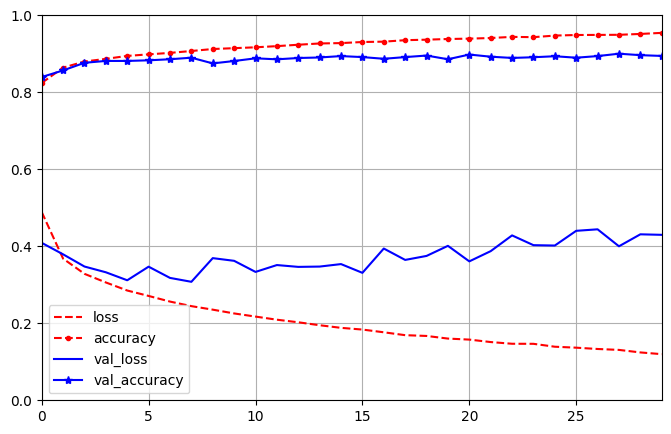

In [24]:
%pip install matplotlib
%pip install pandas

import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True,
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [20]:
Model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 2ms/step - loss: 0.4438 - accuracy: 0.8899


[0.4437544047832489, 0.8899000287055969]